In [1]:
import re
import csv
from datetime import datetime
import numpy as np
import pandas as pd
from scipy import stats as sp_stats
import functions as f
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('QVI_data_2.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  int64         
 1   DATE              264834 non-null  datetime64[ns]
 2   STORE_NBR         264834 non-null  int64         
 3   TXN_ID            264834 non-null  int64         
 4   PROD_NBR          264834 non-null  int64         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int64         
 7   TOT_SALES         264834 non-null  float64       
 8   PACK_SIZE         264834 non-null  int64         
 9   BRAND             264834 non-null  object        
 10  LIFESTAGE         264834 non-null  object        
 11  PREMIUM_CUSTOMER  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


## Data Preparation

This dataset is based on previously cleaned transaction and customer data.

Therefore, the analysis starts from an already prepared dataset rather than repeating the earlier data-cleaning and outlier-treatment steps.

The focus of this notebook is the **store-level trial analysis**:
- Comparing store performance before the trial.
- Identifying suitable control stores.
- Comparing trial stores with matched control stores.
- Evaluating changes in sales, transactions, product quantity, and customer visits.

# Quantium Store Trial Analysis

## Project Objective

The objective of this analysis is to identify suitable control stores for selected trial stores and use those controls to evaluate the impact of the trial.

### Key Questions

1. Which stores have the most similar pre-trial behaviour to each trial store?
2. Do trial and control stores show similar patterns before the trial?
3. Did sales, transactions, product quantity, or customer visits change during the trial period?
4. Is the change at the trial store larger than the change observed at its control store?

### Key Metrics

The store-level analysis focuses on:
- Monthly sales
- Monthly transactions
- Product quantity
- Customer visits

The analysis uses the **pre-trial period** to identify suitable control stores so that the trial period does not influence the control-store selection.

In [3]:
data = df.copy()

num, cat, floating = f.dtype_validator(data)

print(f'Numerical Dtype Col: {num},\nCategorical Dtype Col: {cat}\nFloat Dtype Col: {floating}')

Numerical Dtype Col: ['LYLTY_CARD_NBR', 'STORE_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_QTY', 'PACK_SIZE'],
Categorical Dtype Col: ['PROD_NAME', 'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER']
Float Dtype Col: ['TOT_SALES']


In [4]:
data = f.rename_func(data)

data = f.downcasting(data, num, cat, floating)
data[['LYLTY_CARD_NBR', 'TXN_ID','PROD_NAME']] = data[['LYLTY_CARD_NBR', 'TXN_ID','PROD_NAME']].astype('str')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  object        
 1   DATE              264834 non-null  datetime64[ns]
 2   STORE_NBR         264834 non-null  int16         
 3   TXN_ID            264834 non-null  object        
 4   PROD_NBR          264834 non-null  int16         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int16         
 7   TOT_SALES         264834 non-null  float32       
 8   PACK_SIZE         264834 non-null  int16         
 9   BRAND             264834 non-null  category      
 10  LIFESTAGE         264834 non-null  category      
 11  PREMIUM_CUSTOMER  264834 non-null  category      
dtypes: category(3), datetime64[ns](1), float32(1), int16(4), object(3)
memory usage: 11.9+ MB


In [5]:
data.describe(include= 'all')

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
count,264834,264834,264834.000000,264834,264834.000000,264834,264834.000000,264834.000000,264834.000000,264834,264834,264834
unique,50181,NaN,NaN,65536,NaN,114,NaN,NaN,NaN,21,7,3
top,7101,NaN,NaN,7721,NaN,Kettle Mozzarella Basil Pesto 175g,NaN,NaN,NaN,Kettle,OLDER SINGLES/COUPLES,Mainstream
freq,27,NaN,NaN,7,NaN,3304,NaN,NaN,NaN,41288,54479,101988
mean,NaN,2018-12-30 00:52:10.292937984,135.079423,NaN,56.583554,NaN,1.905813,7.299346,182.425512,NaN,NaN,NaN
min,NaN,2018-07-01 00:00:00,1.000000,NaN,1.000000,NaN,1.000000,1.500000,70.000000,NaN,NaN,NaN
25%,NaN,2018-09-30 00:00:00,70.000000,NaN,28.000000,NaN,2.000000,5.400000,150.000000,NaN,NaN,NaN
50%,NaN,2018-12-30 00:00:00,130.000000,NaN,56.000000,NaN,2.000000,7.400000,170.000000,NaN,NaN,NaN
75%,NaN,2019-03-31 00:00:00,203.000000,NaN,85.000000,NaN,2.000000,9.200000,175.000000,NaN,NaN,NaN
max,NaN,2019-06-30 00:00:00,272.000000,NaN,114.000000,NaN,5.000000,29.500000,380.000000,NaN,NaN,NaN


In [6]:
data['YEAR/MONTH'] = data['DATE'].dt.to_period('M')
data

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEAR/MONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium,2018-10
1,1002,2018-09-16,1,2,58,Red Rock Deli ChiknGarlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09
2,1003,2019-03-07,1,3,52,Grain Waves Sour CreamChives 210G,1,3.6,210,GrnWves,YOUNG FAMILIES,Budget,2019-03
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,Natural,YOUNG FAMILIES,Budget,2019-03
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,Woolworths,OLDER SINGLES/COUPLES,Mainstream,2018-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264829,11405,2018-12-08,88,-21766,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GrnWves,YOUNG FAMILIES,Mainstream,2018-12
264830,11455,2018-10-01,88,-21750,60,Kettle Tortilla ChpsFetaGarlic 150g,2,9.2,150,Kettle,YOUNG FAMILIES,Premium,2018-10
264831,11665,2018-10-24,88,-21664,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,Tyrrells,OLDER FAMILIES,Budget,2018-10
264832,11665,2018-10-27,88,-21663,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,Old,OLDER FAMILIES,Budget,2018-10


## Control Store Selection Method

### Why Compare Stores Before the Trial?

Trial stores and potential control stores may naturally have different sales volumes.

Therefore, comparing their raw sales after the trial would not be enough to determine whether the trial had an effect.

Instead, the control store is selected using **pre-trial behaviour** across multiple performance measures.

A strong candidate should have similar:
- Sales levels and trends
- Transaction activity
- Product quantity
- Customer visit patterns

The goal is to find a store that provides a reasonable representation of the trial store's expected behaviour in the absence of the trial.

In [7]:
def store_pivot(x,y):
    """
    create pivot table where index is 'STORE_NBR', columns is 'YEAR/MONTH
    input required are x, y
    where x= Values and y= aggfunc.
    And Drop any NA value.
    """
    pivot_table = pd.crosstab(
        index= data['STORE_NBR'],
        columns= data['YEAR/MONTH'],
        values= data[x],
        aggfunc= f'{y}'
        )
    
    pivot_table = pivot_table.dropna()

    return pivot_table

prod_sold_by_store = store_pivot('PROD_QTY','sum')

txn_per_store = store_pivot('TXN_ID','count')

customers_per_store = store_pivot('LYLTY_CARD_NBR','nunique')

sale_per_store = store_pivot('TOT_SALES','sum')

monthly_txn_per_cust = txn_per_store/customers_per_store
product_per_cust = prod_sold_by_store/customers_per_store
avg_price_per_unit = sale_per_store/prod_sold_by_store

In [8]:
def find_control_store_scipy(trial_store_nbr, dataframe):
    # 1. Isolate the pre-trial historical window (Before February 2019)
    pre_trial = dataframe.loc[:, dataframe.columns < '2019-02']
    trial_series = pre_trial.loc[trial_store_nbr]
    
    # 2. Find the Max-Min boundaries of the entire dataset to normalize distance
    # This scales everything accurately regardless of whether sales are $100 or $10,000
    global_max = pre_trial.max().max()
    global_min = pre_trial.min().min()
    max_possible_dist = global_max - global_min
    
    scores = {}
    
    for store in pre_trial.index:
        # Avoid checking the trial store against itself or other trial stores
        if store in [77, 86, 88, trial_store_nbr]:
            continue

        control_series = pre_trial.loc[store]
        
        # --- CRITERIA 1: Trend Correlation using Scipy ---
        # pearsonr returns a tuple: (correlation_coefficient, p_value)
        corr_score, p_value = sp_stats.pearsonr(trial_series, control_series)
        
        # --- CRITERIA 2: Magnitude Distance using Min-Max Scaling ---
        abs_distance = np.abs(trial_series - control_series).mean()
        
        # Min-Max Scaling logic: 0 means identical distance, 1 means maximum distance
        normalized_dist = abs_distance / max_possible_dist
        
        # Flip it: 1 becomes perfect similarity, 0 becomes completely different size
        magnitude_score = 1 - normalized_dist
        
        # --- COMBINE BOTH METRICS ---
        # 50% weight to trend, 50% weight to physical scale
        scores[store] = (corr_score * 0.5) + (magnitude_score * 0.5)
        
    # Return the single store number that scored the absolute highest
    best_store = max(scores, key=scores.get)
    return best_store

In [9]:
def find_control_stores(*dataframes, trial_stores=None):
    """
    Find the most common control store across multiple dataframes for each trial store.

    Parameters:
    -----------
    *dataframes : variable number of DataFrames
        Multiple dataframes to analyze (e.g., sale_per_store, prod_sold_by_store, etc.)
    trial_stores : list, optional
        List of trial store numbers. Defaults to [77, 86, 88]

    Returns:
    --------
    dict : {trial_store: control_store} mapping showing the most common control store
           for each trial store across all dataframes
    dict : {trial_store: [list of all possible control stores]} for detailed analysis
    """

    if trial_stores is None:
        trial_stores = [77, 86, 88]

    # Store results for each trial store
    trial_results = {trial: [] for trial in trial_stores}

    # For each dataframe, find control stores for all trial stores
    for dataframe in dataframes:
        for trial in trial_stores:
            control_store = find_control_store_scipy(trial, dataframe)
            trial_results[trial].append(control_store)

    # Find the most common control store for each trial store
    final_controls = {}
    possible_controls = {}  # NEW: Simple dict with only trial_store: [list of stores]

    for trial, controls in trial_results.items():
        # Count occurrences of each control store
        store_counts = {}
        for store in controls:
            store_counts[store] = store_counts.get(store, 0) + 1

        # Find the most common one
        most_common = max(store_counts, key=store_counts.get)
        final_controls[trial] = {
            'control_store': most_common,
            'frequency': store_counts[most_common],
            'total_dataframes': len(dataframes),
            'all_candidates': store_counts
        }

        # NEW: Create simple list of possible stores
        possible_controls[trial] = list(store_counts.keys())

    return final_controls, possible_controls

In [10]:
def plot_pre_trial_store_sale(*dataframes, possible_stores_dict, titles=None):
    """
    Plot pre-trial store sales and metrics comparing trial stores with their possible control stores.
    
    Parameters:
    -----------
    *dataframes : variable number of DataFrames
        Multiple dataframes to analyze (e.g., sale_per_store, prod_sold_by_store, txn_per_store, customers_per_store)
    possible_stores_dict : dict
        Dictionary with format {trial_store: [list of possible control stores]}
    titles : list, optional
        List of titles for each subplot. If None, uses default titles.
    
    Returns:
    --------
    None (displays plots)
    """
    
    n_dfs = len(dataframes)
    n_rows = (n_dfs + 1) // 2
    n_cols = 2
    
    # Default titles if not provided
    if titles is None:
        titles = [f"Metric {i+1}" for i in range(n_dfs)]
    
    # Create figure with dynamic sizing
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    fig.subplots_adjust(hspace=0.35, wspace=0.3)
    
    # Flatten axes for easier iteration (handles both 1D and 2D cases)
    axes = ax.flatten()
    
    # Iterate through each dataframe and plot
    for idx, (dataframe, title) in enumerate(zip(dataframes, titles)):
        axis = axes[idx]
        
        # Process each trial store and its possible control stores
        for trial_store, control_stores in possible_stores_dict.items():
            # Combine trial store with all its possible control stores
            store_list = [int(trial_store)] + [int(cs) for cs in control_stores]
            
            # Filter data: pre-trial period (before 2019-02) and selected stores
            df_filtered = dataframe.loc[store_list, dataframe.columns < '2019-02'].T
            
            # Plot with marker and label
            df_filtered.plot( 
                ax=axis, 
                label=[f"Trial Store {trial_store}"] + [f"Control {cs}" for cs in control_stores]
            )
        
        # Configure subplot
        axis.set_title(title, fontsize=12, fontweight='bold')
        axis.set_xlabel('Year/Month', fontsize=10)
        axis.set_ylabel('Value', fontsize=10)
        axis.grid(True, alpha=0.3)
        
        # Alternating legend position
        legend_pos = (-0.15, 1) if idx % 2 == 0 else (1.02, 1)
        axis.legend(bbox_to_anchor=legend_pos, loc='upper left', fontsize=9)
    
    # Hide extra subplots if n_dfs is odd
    for idx in range(n_dfs, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## Pre-Trial Control Validation

### Business Question

Do the selected trial and control stores move similarly before the trial begins?

A good control should not only have similar average performance but should also demonstrate similar pre-trial trends.

The comparison therefore examines the monthly behaviour of:
- Sales
- Transactions
- Product quantity
- Customer visits

Visual trend comparisons and similarity measures can be used together to validate the selected control store.

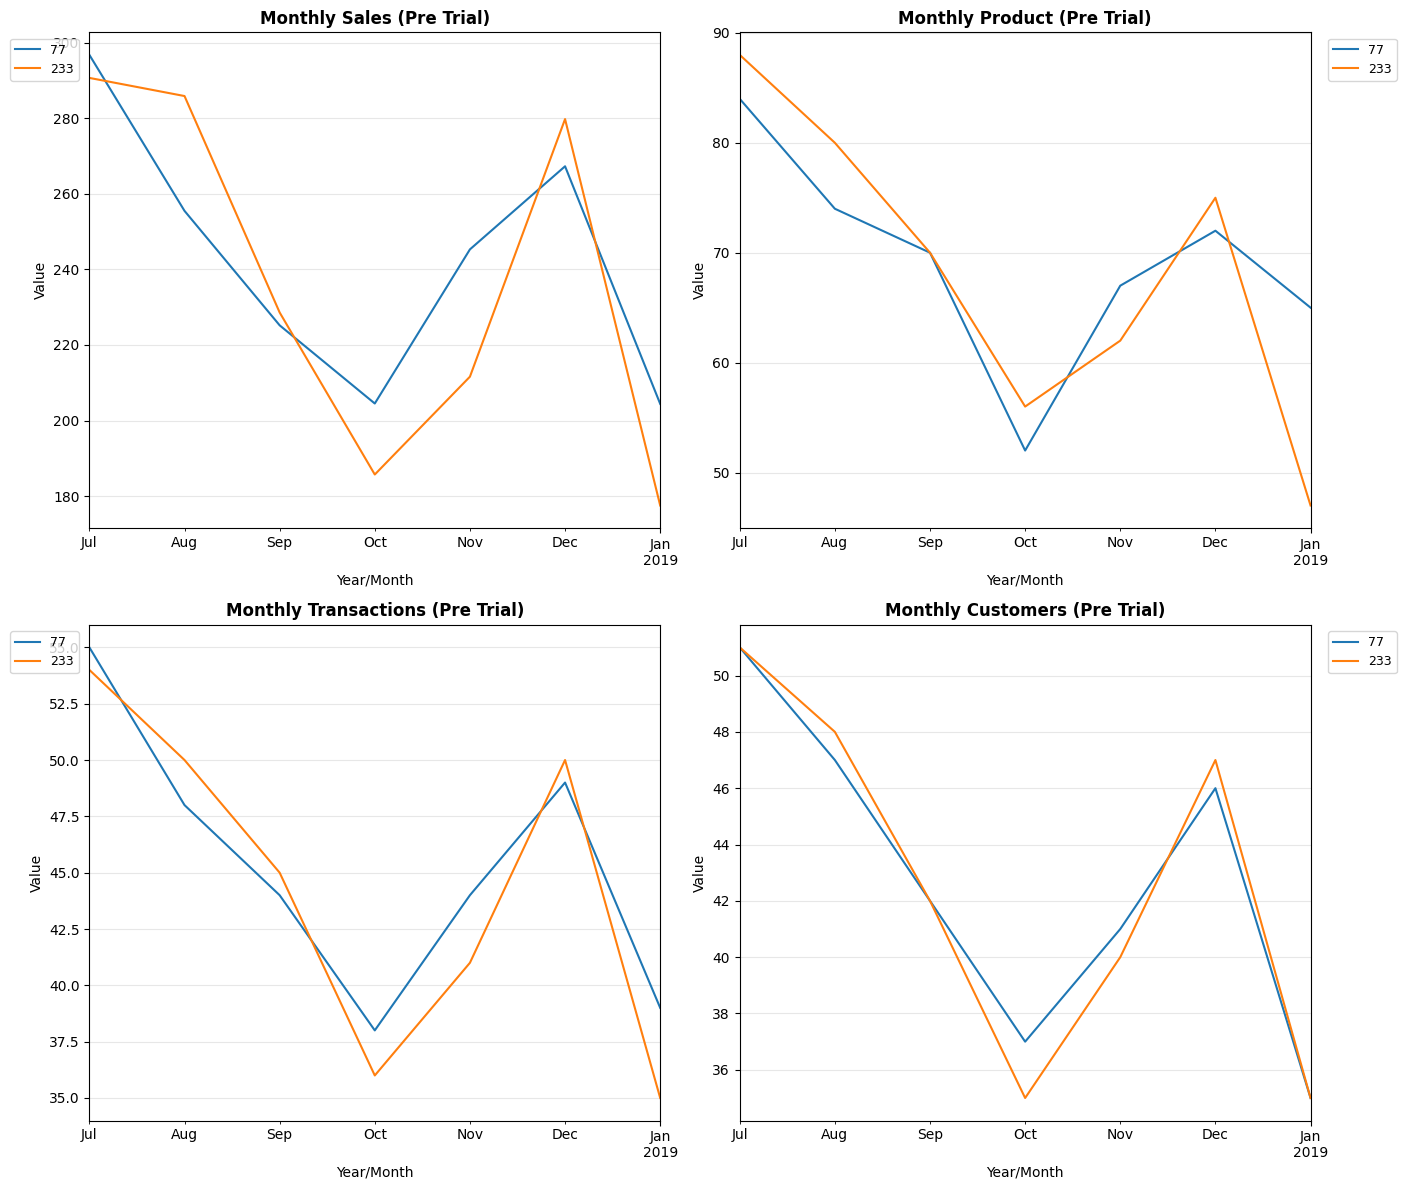

In [11]:
detailed_result_77, possible_stores_77 = find_control_stores(
    sale_per_store, 
    prod_sold_by_store, 
    txn_per_store, 
    customers_per_store,
    trial_stores= [77]
)
# Plot with custom titles
plot_pre_trial_store_sale(
    sale_per_store,
    prod_sold_by_store,
    txn_per_store,
    customers_per_store,
    possible_stores_dict=possible_stores_77,
    titles=[
        "Monthly Sales (Pre Trial)",
        "Monthly Product (Pre Trial)",
        "Monthly Transactions (Pre Trial)",
        "Monthly Customers (Pre Trial)"
    ]
)

### Control Store Selection — Trial Store 77

- Store **233** is identified as a suitable control candidate for Trial Store **77** based on the pre-trial store-performance comparison.

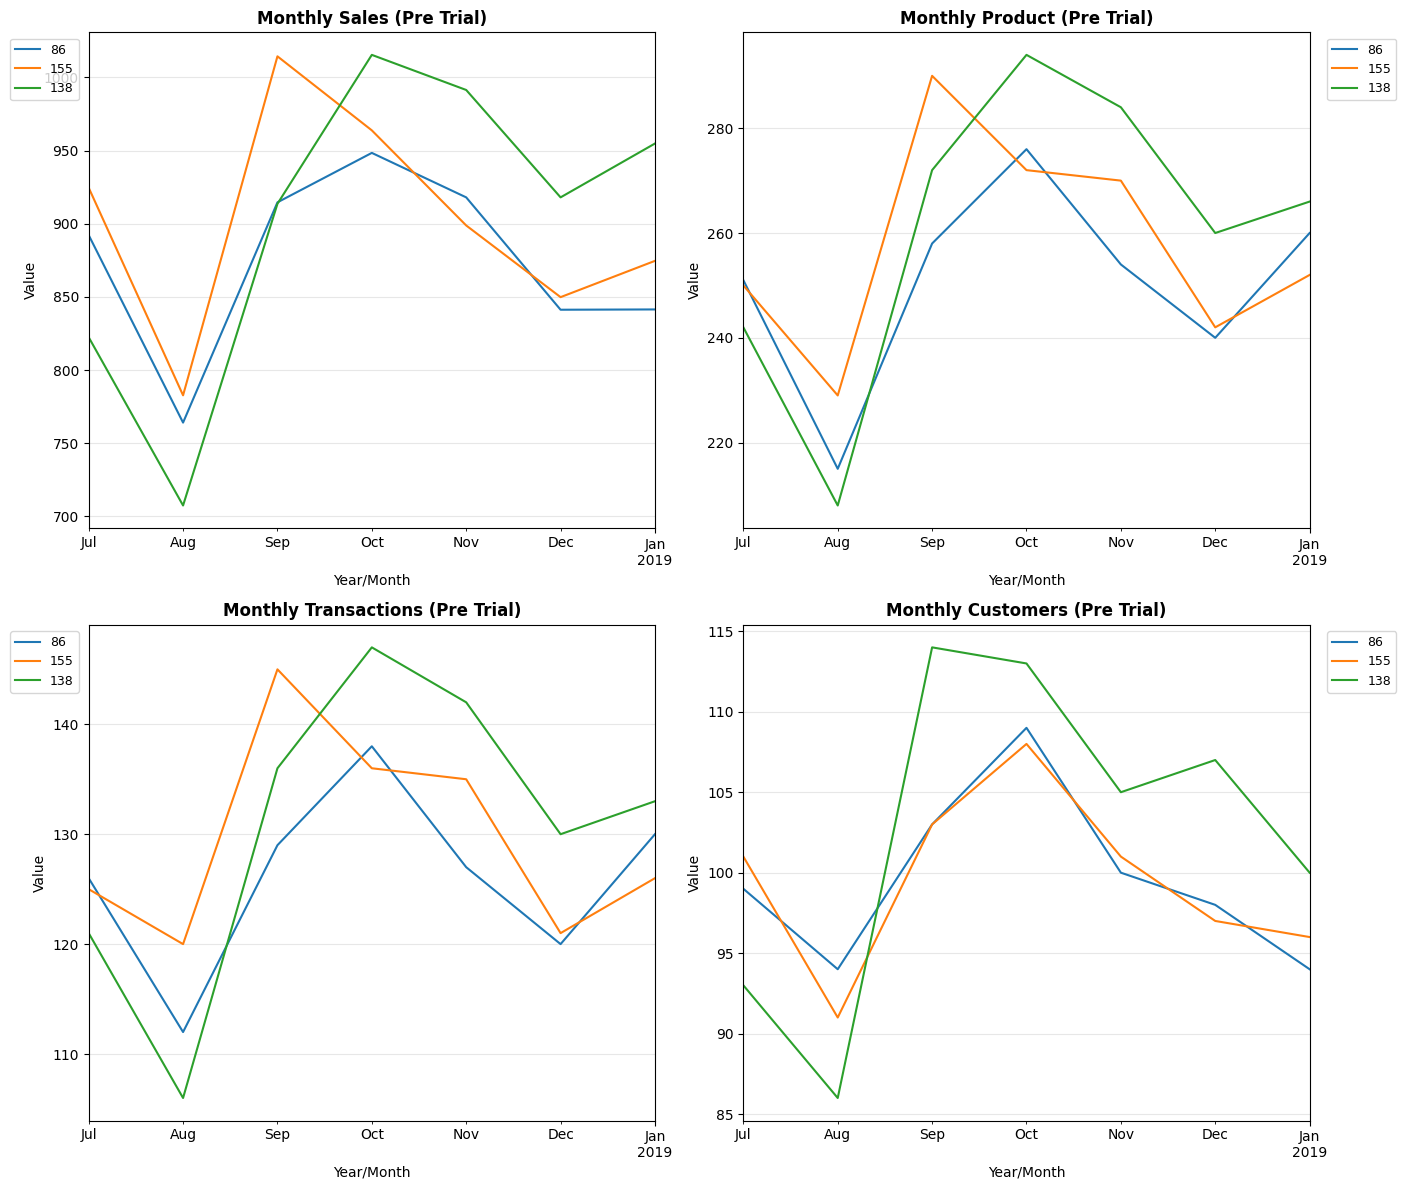

In [12]:
detailed_result_86, possible_stores_86 = find_control_stores(
    sale_per_store, 
    prod_sold_by_store, 
    txn_per_store, 
    customers_per_store,
    trial_stores= [86]
)
# Plot with custom titles
plot_pre_trial_store_sale(
    sale_per_store,
    prod_sold_by_store,
    txn_per_store,
    customers_per_store,
    possible_stores_dict=possible_stores_86,
    titles=[
        "Monthly Sales (Pre Trial)",
        "Monthly Product (Pre Trial)",
        "Monthly Transactions (Pre Trial)",
        "Monthly Customers (Pre Trial)"
    ]
)

### Control Store Selection — Trial Store 86

- Store **155** shows a strong pre-trial similarity to Trial Store **86** across the store-performance metrics examined.

- Although monthly sales, transactions, product quantity, and customer visits naturally vary over time, the overall pre-trial behaviour makes Store 155 a suitable candidate for further trial-effect analysis.

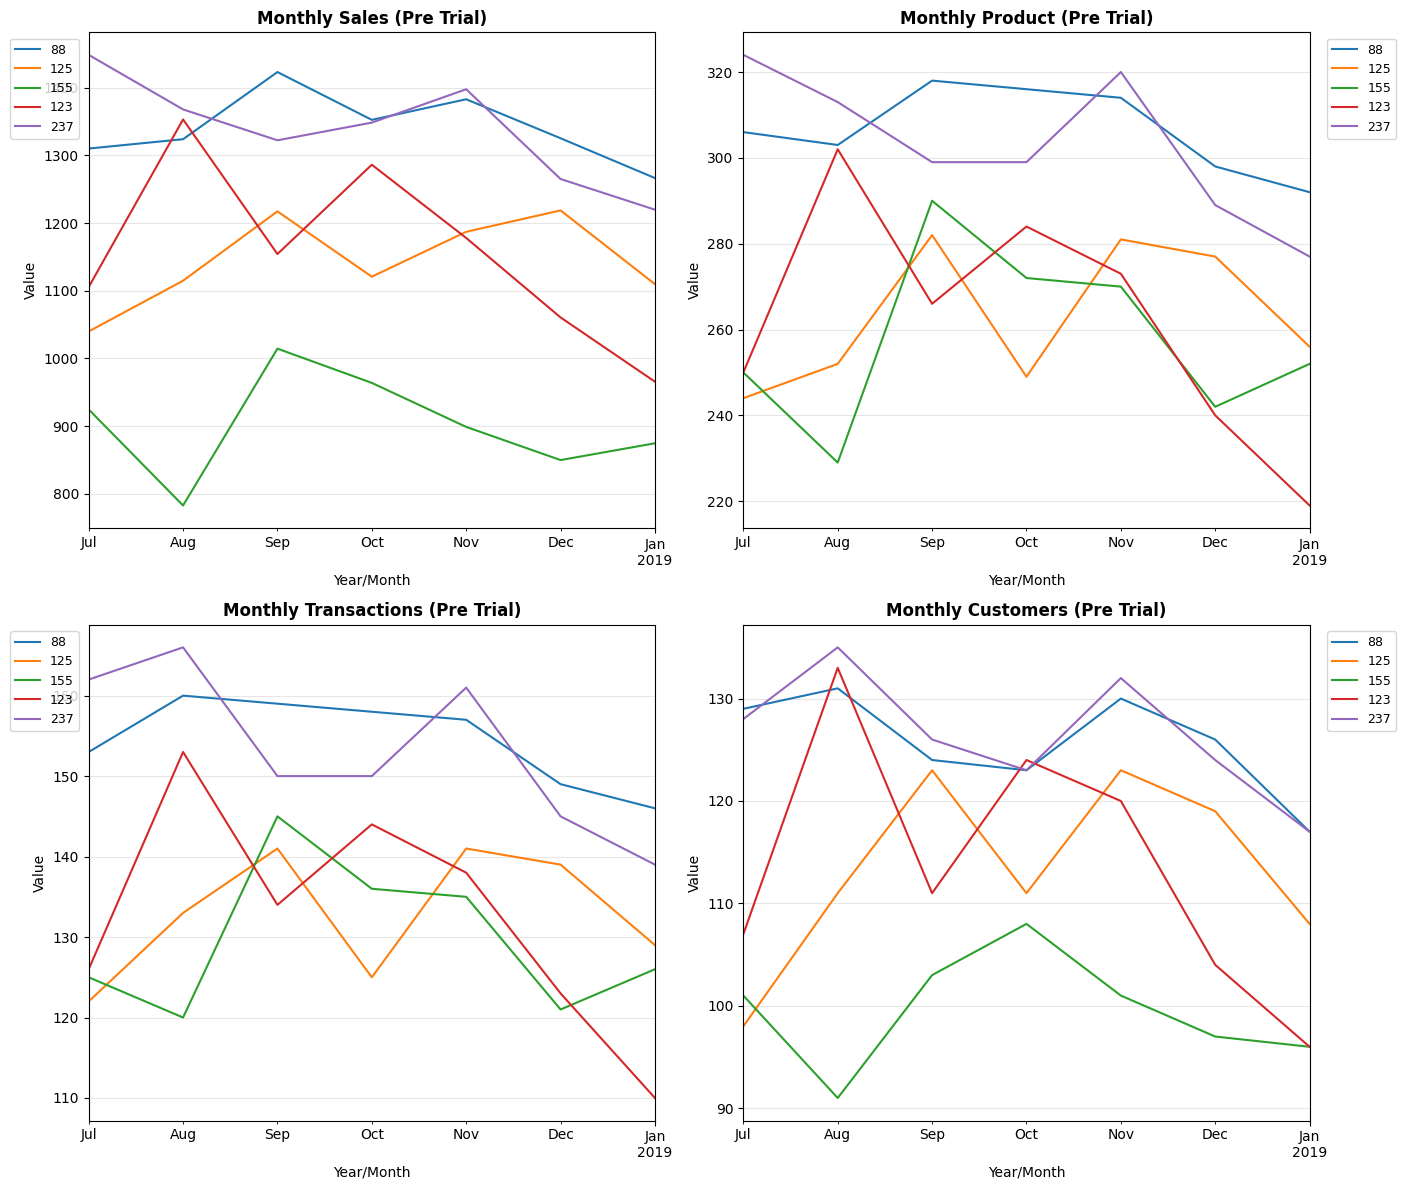

In [13]:
detailed_result_88, possible_stores_88 = find_control_stores(
    sale_per_store, 
    prod_sold_by_store, 
    txn_per_store, 
    customers_per_store,
    trial_stores= [88]
)
# Plot with custom titles
plot_pre_trial_store_sale(
    sale_per_store,
    prod_sold_by_store,
    txn_per_store,
    customers_per_store,
    possible_stores_dict=possible_stores_88,
    titles=[
        "Monthly Sales (Pre Trial)",
        "Monthly Product (Pre Trial)",
        "Monthly Transactions (Pre Trial)",
        "Monthly Customers (Pre Trial)"
    ]
)

### Control Store Selection — Trial Store 88

- Store **237** shows a strong pre-trial similarity to Trial Store **88** across the selected store-performance metrics.

- This store will be treated as the candidate control for the next stage of analysis.

In [14]:
def plot_trial_store(*dataframes, possible_stores_dict, titles=None):
    """
    Plot pre-trial store sales and metrics comparing trial stores with their possible control stores.
    
    Parameters:
    -----------
    *dataframes : variable number of DataFrames
        Multiple dataframes to analyze (e.g., sale_per_store, prod_sold_by_store, txn_per_store, customers_per_store)
    possible_stores_dict : dict
        Dictionary with format {trial_store: [list of possible control stores]}
    titles : list, optional
        List of titles for each subplot. If None, uses default titles.
    
    Returns:
    --------
    None (displays plots)
    """
    
    n_dfs = len(dataframes)
    n_rows = (n_dfs + 1) // 2
    n_cols = 2
    
    # Default titles if not provided
    if titles is None:
        titles = [f"Metric {i+1}" for i in range(n_dfs)]
    
    # Create figure with dynamic sizing
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    fig.subplots_adjust(hspace=0.35, wspace=0.3)
    
    # Flatten axes for easier iteration (handles both 1D and 2D cases)
    axes = ax.flatten()
    
    # Iterate through each dataframe and plot
    for idx, (dataframe, title) in enumerate(zip(dataframes, titles)):
        axis = axes[idx]
        
        # Process each trial store and its possible control stores
        for trial_store, control_stores in possible_stores_dict.items():
            # Combine trial store with all its possible control stores
            store_list = [int(trial_store)] + [int(cs) for cs in control_stores]
            
            # Filter data: pre-trial period (before 2019-02) and selected stores
            df_filtered = dataframe.loc[store_list, dataframe.columns >= '2019-02'].T
            
            # Plot with marker and label
            df_filtered.plot( 
                ax=axis, 
                label=[f"Trial Store {trial_store}"] + [f"Control {cs}" for cs in control_stores]
            )
        
        # Configure subplot
        axis.set_title(title, fontsize=12, fontweight='bold')
        axis.set_xlabel('Year/Month', fontsize=10)
        axis.set_ylabel('Value', fontsize=10)
        axis.grid(True, alpha=0.3)
        
        # Alternating legend position
        legend_pos = (-0.15, 1) if idx % 2 == 0 else (1.02, 1)
        axis.legend(bbox_to_anchor=legend_pos, loc='upper left', fontsize=9)
    
    # Hide extra subplots if n_dfs is odd
    for idx in range(n_dfs, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

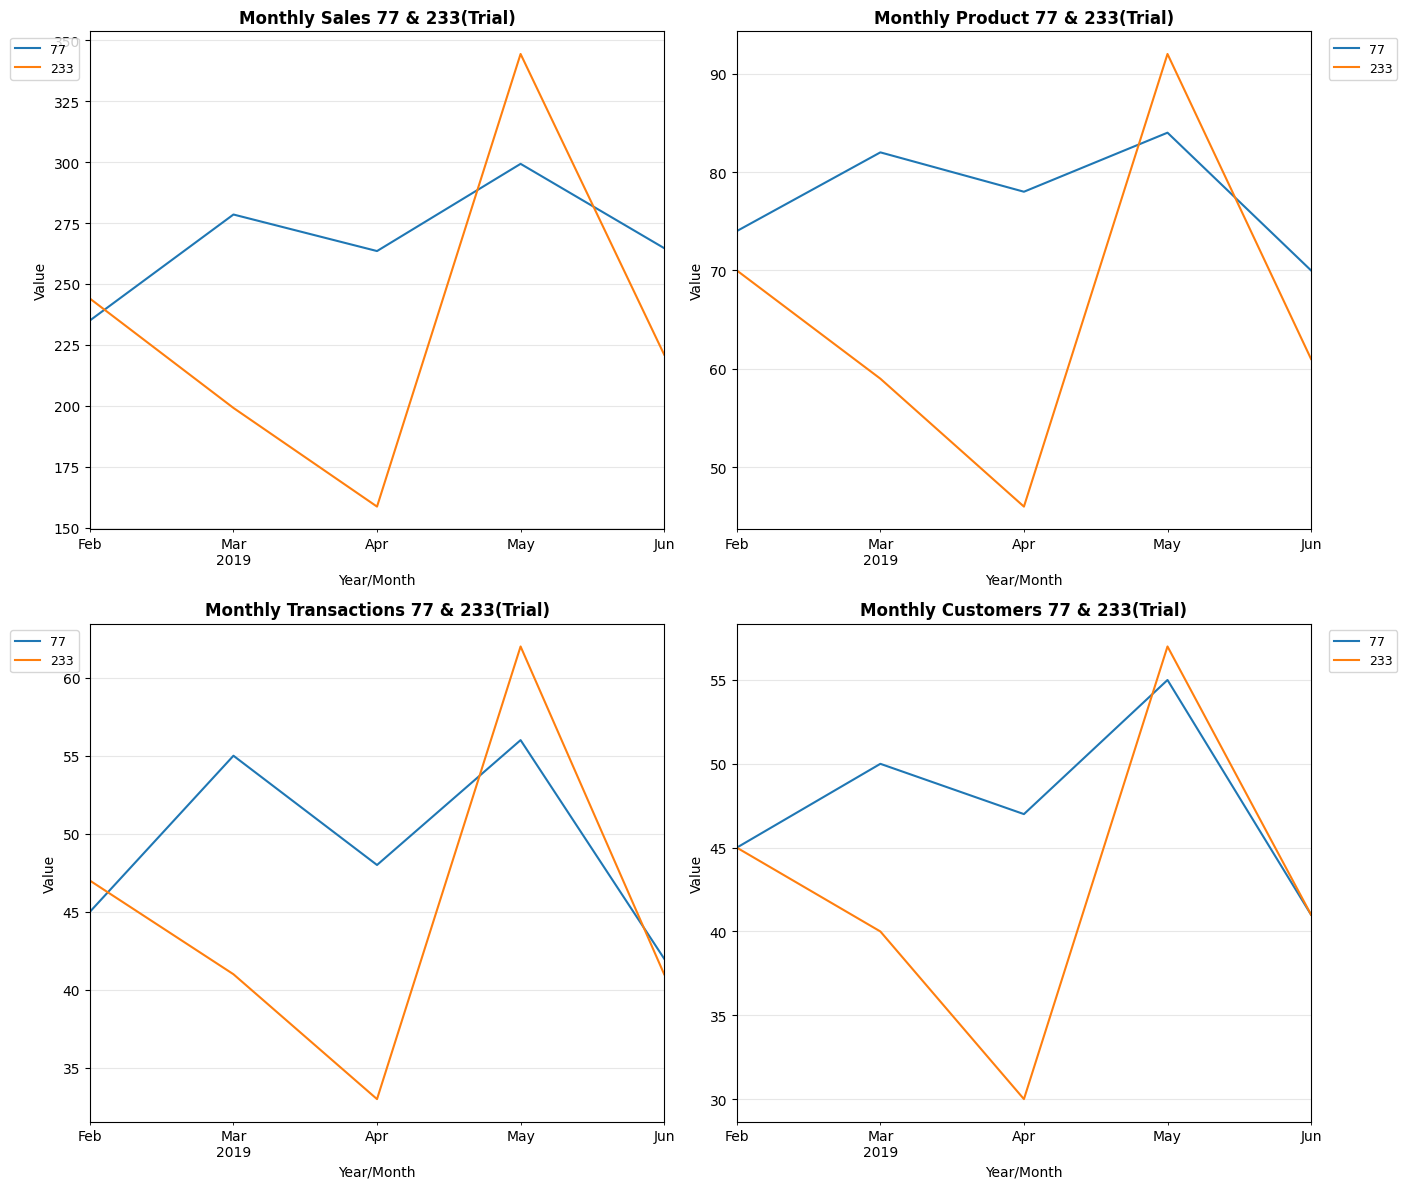

In [15]:
plot_trial_store(sale_per_store, prod_sold_by_store, txn_per_store, customers_per_store, possible_stores_dict={77: [233]}, titles=[
        "Monthly Sales 77 & 233(Trial)",
        "Monthly Product 77 & 233(Trial)",
        "Monthly Transactions 77 & 233(Trial)",
        "Monthly Customers 77 & 233(Trial)"
    ])

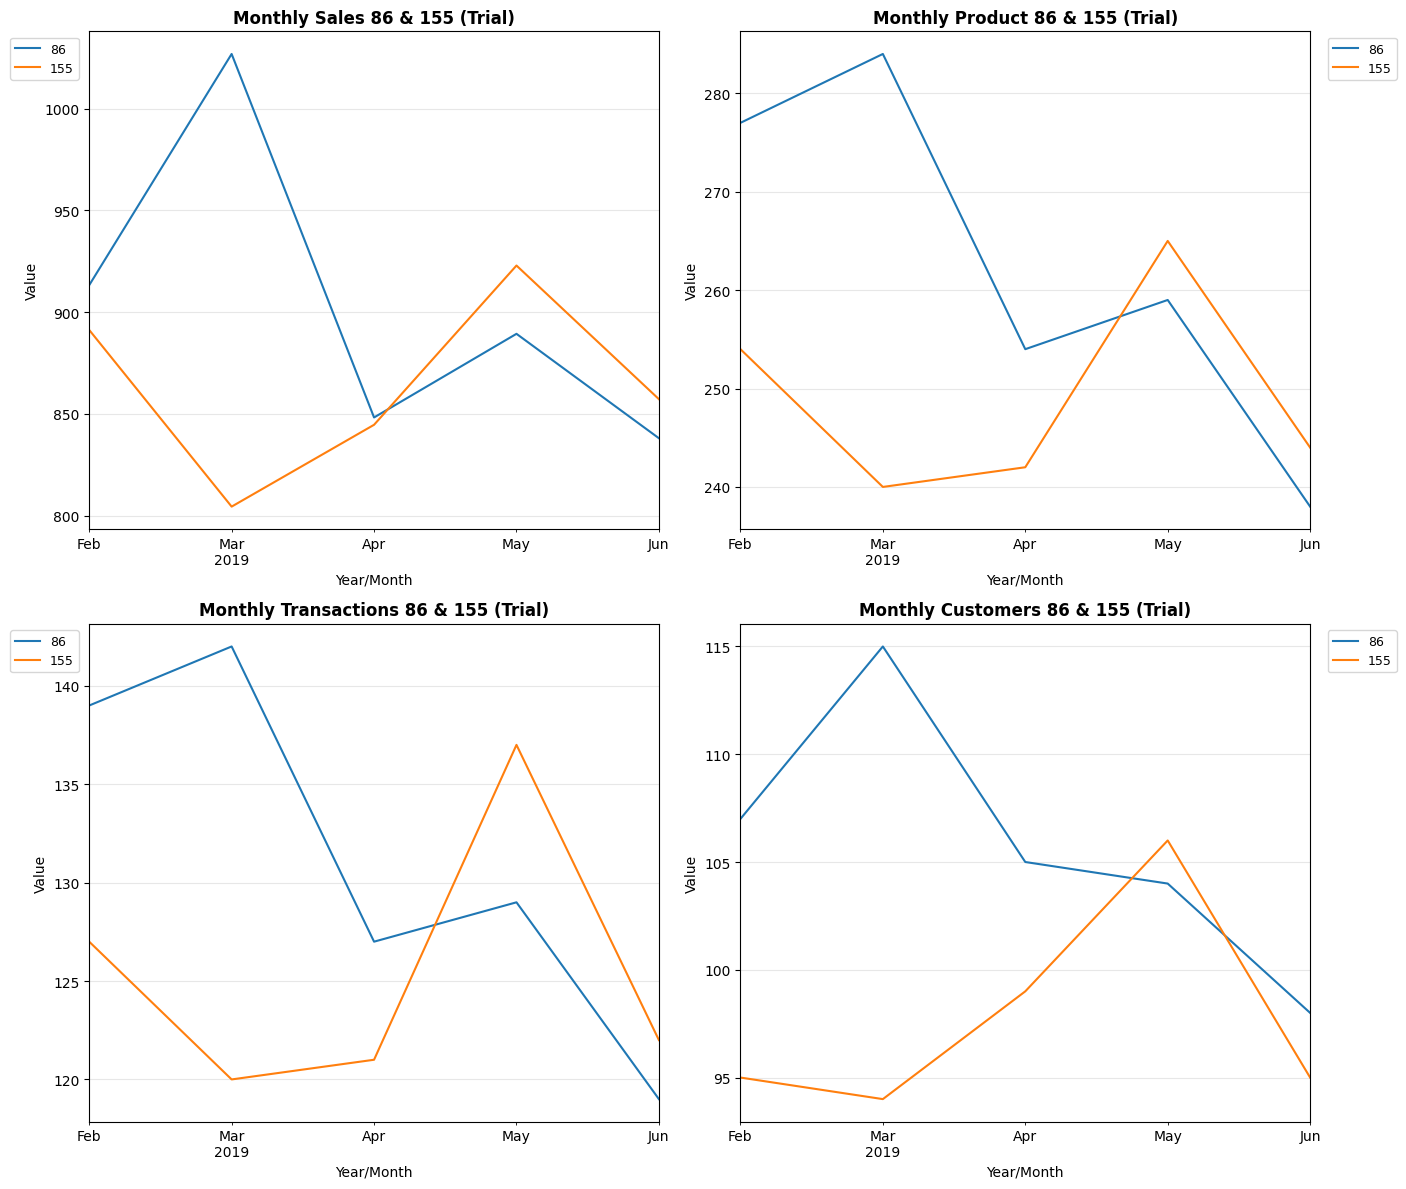

In [16]:
plot_trial_store(sale_per_store, prod_sold_by_store, txn_per_store, customers_per_store, possible_stores_dict={86: [155]}, titles=[
        "Monthly Sales 86 & 155 (Trial)",
        "Monthly Product 86 & 155 (Trial)",
        "Monthly Transactions 86 & 155 (Trial)",
        "Monthly Customers 86 & 155 (Trial)"
    ])

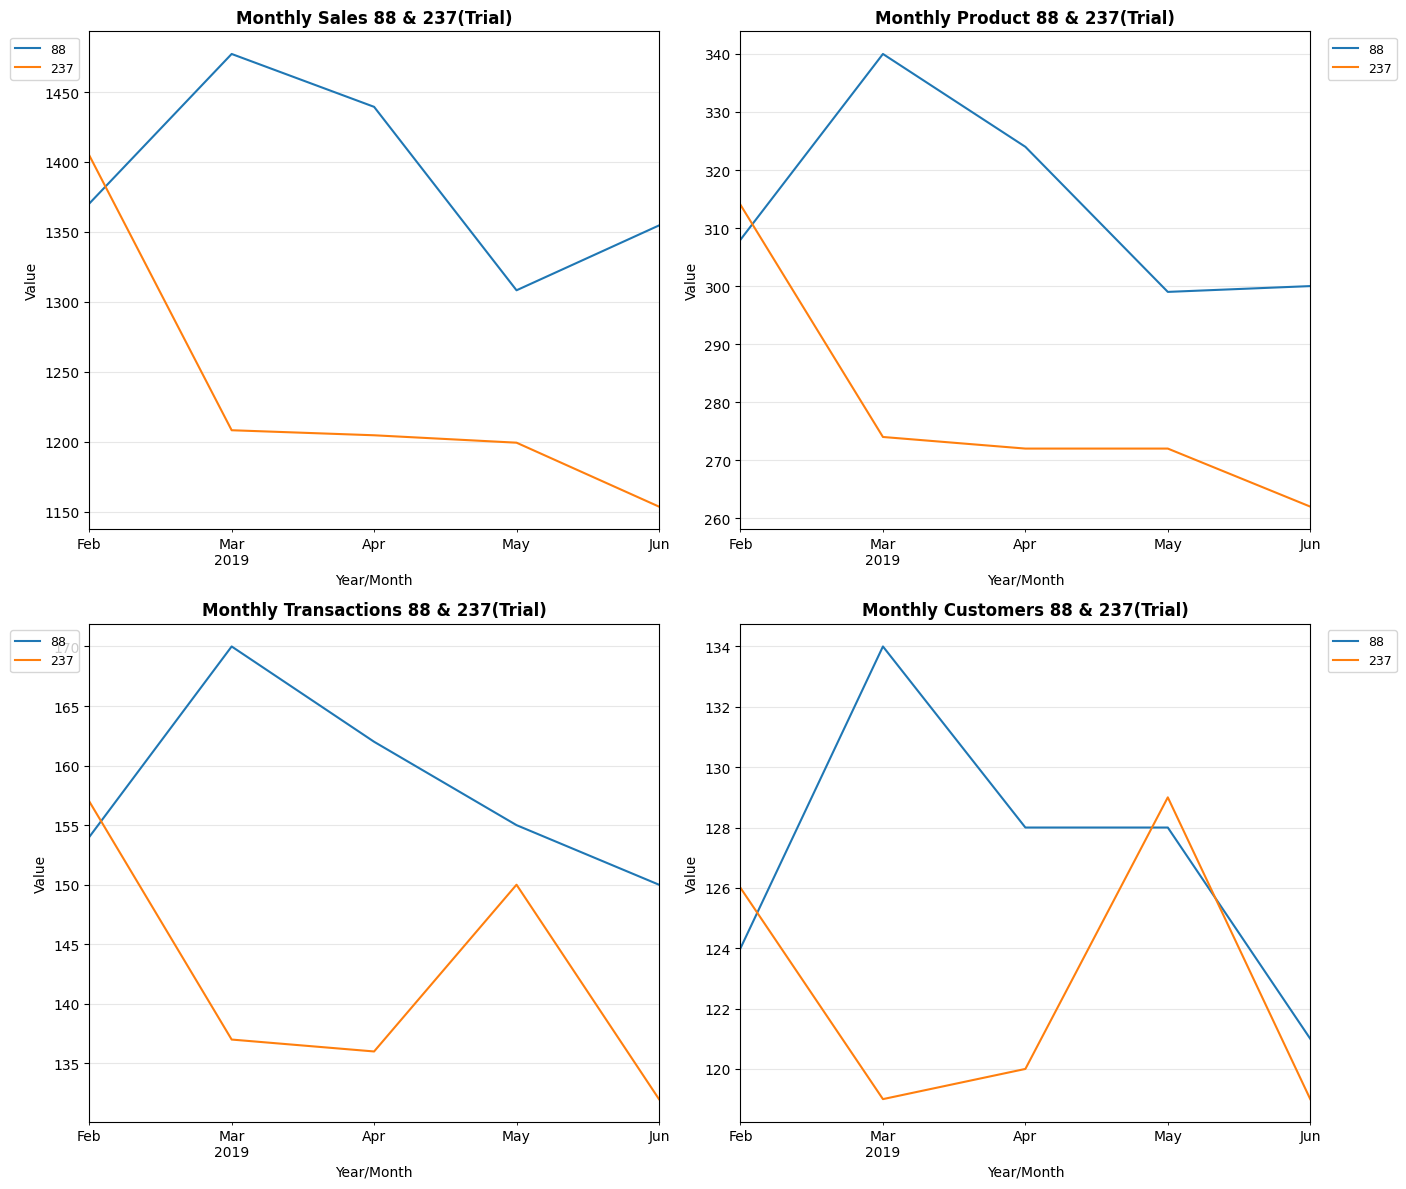

In [17]:
plot_trial_store(sale_per_store, prod_sold_by_store, txn_per_store, customers_per_store, possible_stores_dict={88: [237]}, titles=[
        "Monthly Sales 88 & 237(Trial)",
        "Monthly Product 88 & 237(Trial)",
        "Monthly Transactions 88 & 237(Trial)",
        "Monthly Customers 88 & 237(Trial)"
    ])

In [18]:
sales_77_233 = sale_per_store.loc[[77,233], "2019-02":]
sales_86_155 = sale_per_store.loc[[86,155], "2019-02":]
sales_88_237 = sale_per_store.loc[[88,237], "2019-02":]

revenue_pct_77 = (sales_77_233.loc[77] - sales_77_233.loc[233]) * 100 / sales_77_233.loc[233]
revenue_pct_86 = (sales_86_155.loc[86] - sales_86_155.loc[155]) * 100 / sales_86_155.loc[155]
revenue_pct_88 = (sales_88_237.loc[88] - sales_88_237.loc[237]) * 100 / sales_88_237.loc[237]

print(f"Revenue for store 77\n{revenue_pct_77}\n")
print(f"Revenue for store 86\n{revenue_pct_86}\n")
print(f"Revenue for store 88\n{revenue_pct_88}\n")

print(f"Average Overall Revenue:\nFor 77 : {round(revenue_pct_77.mean(),2)}%")
print(f"For 86: {round(revenue_pct_86.mean(),2)}%")
print(f"For 88: {round(revenue_pct_88.mean(),2)}%")

Revenue for store 77
YEAR/MONTH
2019-02    -3.688524
2019-03    39.879456
2019-04    66.141228
2019-05   -13.095240
2019-06    19.773760
Freq: M, dtype: float32

Revenue for store 86
YEAR/MONTH
2019-02     2.468582
2019-03    27.647947
2019-04     0.426242
2019-05    -3.635476
2019-06    -2.239852
Freq: M, dtype: float32

Revenue for store 88
YEAR/MONTH
2019-02    -2.462991
2019-03    22.264526
2019-04    19.491951
2019-05     9.084461
2019-06    17.423717
Freq: M, dtype: float32

Average Overall Revenue:
For 77 : 21.799999237060547%
For 86: 4.929999828338623%
For 88: 13.15999984741211%


# Final Summary

The analysis follows a store-trial evaluation framework:

**Pre-Trial Store Data** -> **Control Store Matching** -> **Pre-Trial Trend Validation**
-> **Trial vs Control Comparison**
-> **Difference-in-Differences**